In [ ]:
from google.colab import files

uploaded = files.upload()

filename = next(iter(uploaded))
print("Uploaded file:", filename)

Saving RELIANCE.NS_1973-05-08_2025-03-01.xlsx to RELIANCE.NS_1973-05-08_2025-03-01.xlsx
Uploaded file: RELIANCE.NS_1973-05-08_2025-03-01.xlsx


In [ ]:
import pandas as pd

df = pd.read_excel(filename)

print(df.head())


                        date      open      high       low     close  \
0  1996-01-01 00:00:00+05:30  7.319124  7.358397  7.270925  7.345901   
1  1996-01-02 00:00:00+05:30   7.32805  7.363753  7.235222  7.288776   
2  1996-01-03 00:00:00+05:30  7.408381  7.745775   7.32805  7.344116   
3  1996-01-04 00:00:00+05:30  7.274495  7.297702  7.178097   7.27628   
4  1996-01-05 00:00:00+05:30  7.247718  7.247718  7.163816  7.226296   

  adj_close     volume  
0  3.353593  104121369  
1  3.327513  168743308  
2  3.352778  209323879  
3  3.321809  216900264  
4   3.29899  166708467  


In [ ]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Upload Excel file
uploaded = files.upload()


filename = next(iter(uploaded))
print("Uploaded file:", filename)
df = pd.read_excel(filename)

print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Saving RELIANCE.NS_1973-05-08_2025-03-01.xlsx to RELIANCE.NS_1973-05-08_2025-03-01 (1).xlsx
Uploaded file: RELIANCE.NS_1973-05-08_2025-03-01 (1).xlsx
Rows and columns: (7329, 7)

Column names:
['date', 'open', 'high', 'low', 'close', 'adj_close', 'volume']

First 5 rows:


,date,open,high,low,close,adj_close,volume
0,1996-01-01 00:00:00+05:30,7.319124,7.358397,7.270925,7.345901,3.353593,104121369
1,1996-01-02 00:00:00+05:30,7.32805,7.363753,7.235222,7.288776,3.327513,168743308
2,1996-01-03 00:00:00+05:30,7.408381,7.745775,7.32805,7.344116,3.352778,209323879
3,1996-01-04 00:00:00+05:30,7.274495,7.297702,7.178097,7.27628,3.321809,216900264
4,1996-01-05 00:00:00+05:30,7.247718,7.247718,7.163816,7.226296,3.29899,166708467


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
date         1
open         1
high         1
low          1
close        1
adj_close    1
volume       1
dtype: int64

Data types:
date         object
open         object
high         object
low          object
close        object
adj_close    object
volume       object
dtype: object


In [ ]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
date         1
open         1
high         1
low          1
close        1
adj_close    1
volume       1
dtype: int64

Data types:
date         object
open         object
high         object
low          object
close        object
adj_close    object
volume       object
dtype: object


In [ ]:

df = df.dropna(how="all")


df["date"] = pd.to_datetime(df["date"], errors="coerce")


df = df.dropna(subset=["date"])


numeric_columns = ["open", "high", "low", "close", "adj_close", "volume"]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df = df.dropna(subset=numeric_columns)


df = df.sort_values("date").reset_index(drop=True)

print("Cleaned dataset shape:", df.shape)
display(df.head())
display(df.tail())

Cleaned dataset shape: (7324, 7)


,date,open,high,low,close,adj_close,volume
0,1996-01-01 00:00:00+05:30,7.319124,7.358397,7.270925,7.345901,3.353593,104121369
1,1996-01-02 00:00:00+05:30,7.328050,7.363753,7.235222,7.288776,3.327513,168743308
2,1996-01-03 00:00:00+05:30,7.408381,7.745775,7.328050,7.344116,3.352778,209323879
3,1996-01-04 00:00:00+05:30,7.274495,7.297702,7.178097,7.276280,3.321809,216900264
4,1996-01-05 00:00:00+05:30,7.247718,7.247718,7.163816,7.226296,3.298990,166708467


,date,open,high,low,close,adj_close,volume
7319,2025-02-21 00:00:00+05:30,1228.699951,1240.000000,1222.150024,1228.150024,1228.150024,6904025
7320,2025-02-24 00:00:00+05:30,1216.550049,1223.250000,1210.500000,1214.550049,1214.550049,7172498
7321,2025-02-25 00:00:00+05:30,1211.000000,1221.000000,1201.500000,1204.000000,1204.000000,11552182
7322,2025-02-27 00:00:00+05:30,1212.800049,1215.000000,1200.650024,1207.099976,1207.099976,11509215
7323,2025-02-28 00:00:00+05:30,1202.000000,1217.349976,1193.300049,1200.099976,1200.099976,23007298


In [ ]:

df["daily_return"] = df["close"].pct_change() * 100
print("Daily Return:")
display(df[["date", "close", "daily_return"]].head(10))

Daily Return:


,date,close,daily_return
0,1996-01-01 00:00:00+05:30,7.345901,NaN
1,1996-01-02 00:00:00+05:30,7.288776,-0.777646
2,1996-01-03 00:00:00+05:30,7.344116,0.759254
3,1996-01-04 00:00:00+05:30,7.276280,-0.923682
4,1996-01-05 00:00:00+05:30,7.226296,-0.686944
5,1996-01-08 00:00:00+05:30,6.937101,-4.001982
6,1996-01-09 00:00:00+05:30,6.737164,-2.882139
7,1996-01-10 00:00:00+05:30,6.564004,-2.570222
8,1996-01-11 00:00:00+05:30,6.769297,3.127560
9,1996-01-12 00:00:00+05:30,6.697891,-1.054849


In [ ]:
print("Risk Statistics")
print("----------------")

print("Average Daily Return:", df["daily_return"].mean(), "%")
print("Daily Volatility:", df["daily_return"].std(), "%")
print("Maximum Daily Gain:", df["daily_return"].max(), "%")
print("Maximum Daily Loss:", df["daily_return"].min(), "%")

Risk Statistics
----------------
Average Daily Return: 0.1354381535649297 %
Daily Volatility: 4.764905877905881 %
Maximum Daily Gain: 337.4775217734167 %
Maximum Daily Loss: -76.99449466310963 %


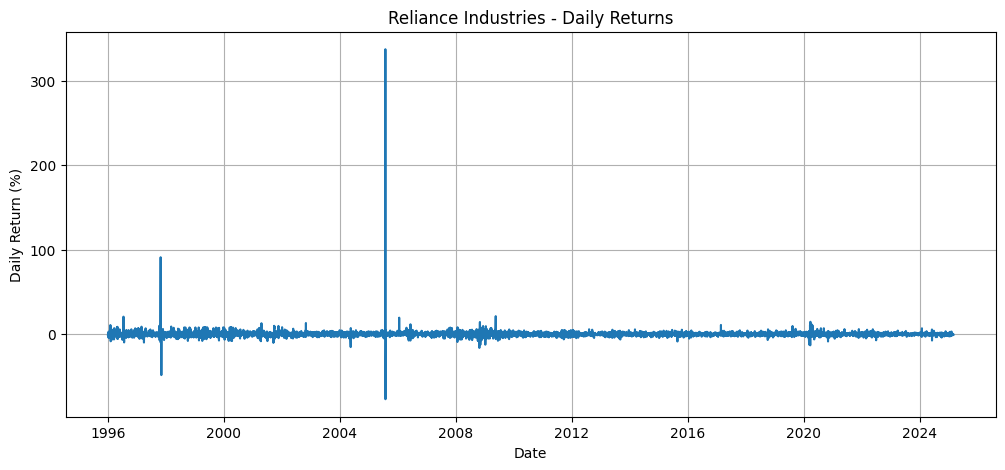

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["daily_return"])

plt.title("Reliance Industries - Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)

plt.show()

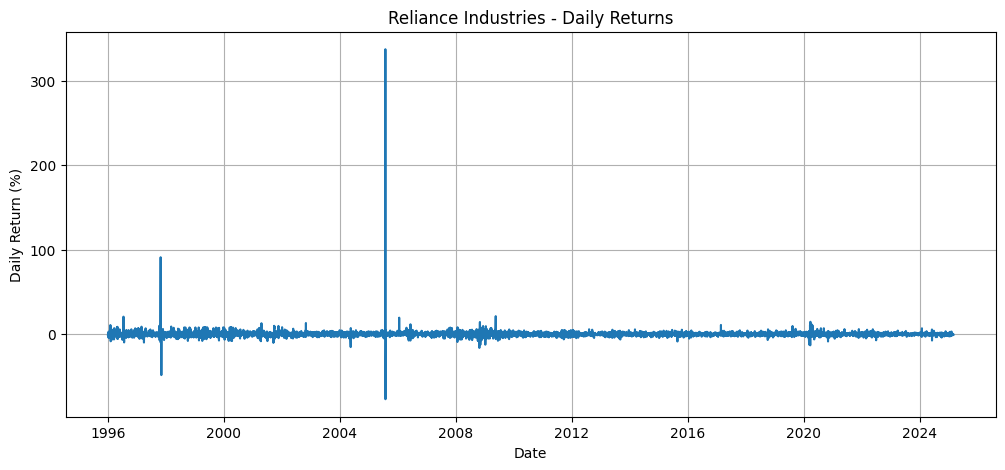

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["daily_return"])

plt.title("Reliance Industries - Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.grid(True)

plt.savefig("reliance_daily_returns.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["drawdown"])

plt.title("Reliance Industries - Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)

plt.savefig("reliance_drawdown.png", dpi=300, bbox_inches="tight")

plt.show()

KeyError: 'drawdown'

<Figure size 1200x500 with 0 Axes>

Worst Drawdown:
Date: 2005-08-23 00:00:00+05:30
Closing Price: 48.92
Drawdown: -77.59 %


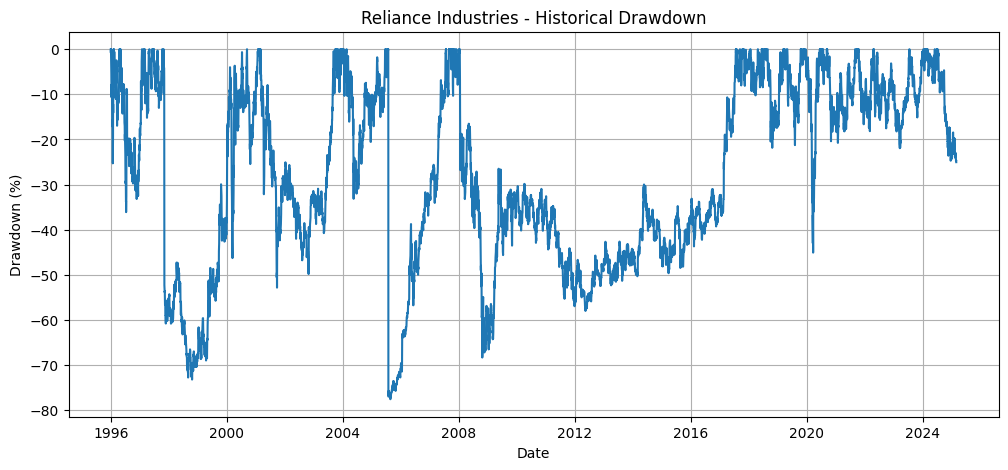

In [ ]:
# Calculate the running maximum closing price
df["running_max"] = df["close"].cummax()

# Calculate drawdown percentage
df["drawdown"] = (
    (df["close"] - df["running_max"])
    / df["running_max"]
) * 100

# Display the worst drawdown
worst_drawdown = df.loc[df["drawdown"].idxmin()]

print("Worst Drawdown:")
print("Date:", worst_drawdown["date"])
print("Closing Price:", round(worst_drawdown["close"], 2))
print("Drawdown:", round(worst_drawdown["drawdown"], 2), "%")

# Create drawdown chart
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["drawdown"])

plt.title("Reliance Industries - Historical Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")
plt.grid(True)

# Save chart
plt.savefig(
    "reliance_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Calculate daily volume change
df["volume_change"] = df["volume"].pct_change() * 100

print("Average Trading Volume:",
      round(df["volume"].mean(), 2))

print("Maximum Trading Volume:",
      df["volume"].max())

print("Minimum Trading Volume:",
      df["volume"].min())

Average Trading Volume: 59388015.53
Maximum Trading Volume: 1448889005
Minimum Trading Volume: 0


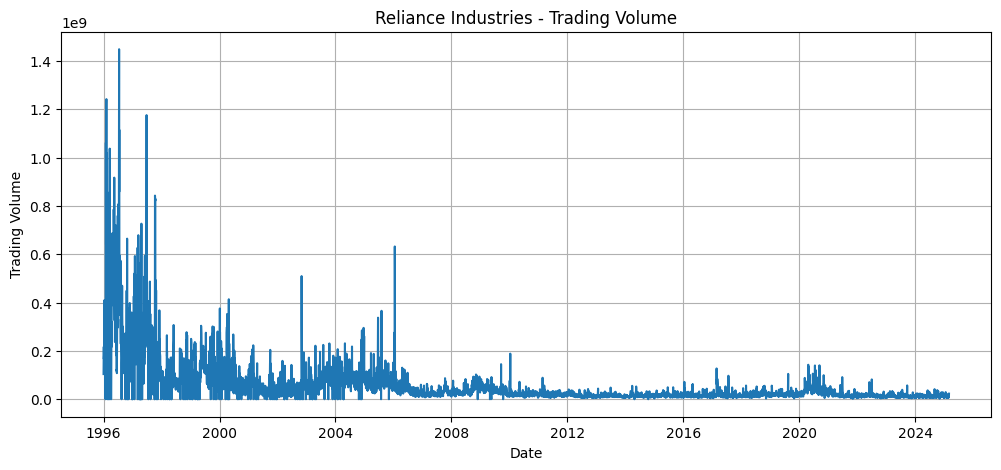

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["volume"])

plt.title("Reliance Industries - Trading Volume")
plt.xlabel("Date")
plt.ylabel("Trading Volume")
plt.grid(True)

plt.savefig(
    "reliance_trading_volume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
print("Average Trading Volume:", round(df["volume"].mean(), 2))
print("Maximum Trading Volume:", df["volume"].max())
print("Minimum Trading Volume:", df["volume"].min())

Average Trading Volume: 59388015.53
Maximum Trading Volume: 1448889005
Minimum Trading Volume: 0


In [ ]:
top_volume = df.nlargest(10, "volume")[[
    "date", "close", "volume", "daily_return"
]]

print("Top 10 Highest Volume Days:")
display(top_volume)

Top 10 Highest Volume Days:


,date,close,volume,daily_return
140,1996-07-15 00:00:00+05:30,6.410481,1448889005,5.555539
26,1996-02-06 00:00:00+05:30,7.220940,1242315590,-8.380526
25,1996-02-05 00:00:00+05:30,7.881447,1222482548,8.316982
388,1997-06-26 00:00:00+05:30,13.556446,1176069141,3.025373
142,1996-07-17 00:00:00+05:30,7.879662,1115459465,1.775423
21,1996-01-30 00:00:00+05:30,6.451540,1061936020,8.986747
56,1996-03-19 00:00:00+05:30,7.026359,1037292464,-6.151641
31,1996-02-13 00:00:00+05:30,8.408067,1019034918,6.009457
29,1996-02-09 00:00:00+05:30,8.461621,994440377,5.803570
30,1996-02-12 00:00:00+05:30,7.931431,971599188,-6.265826


In [ ]:
daily_volatility = df["daily_return"].std()

annualized_volatility = daily_volatility * np.sqrt(252)

print("Daily Volatility:", round(daily_volatility, 2), "%")
print("Annualized Volatility:", round(annualized_volatility, 2), "%")

Daily Volatility: 4.76 %
Annualized Volatility: 75.64 %


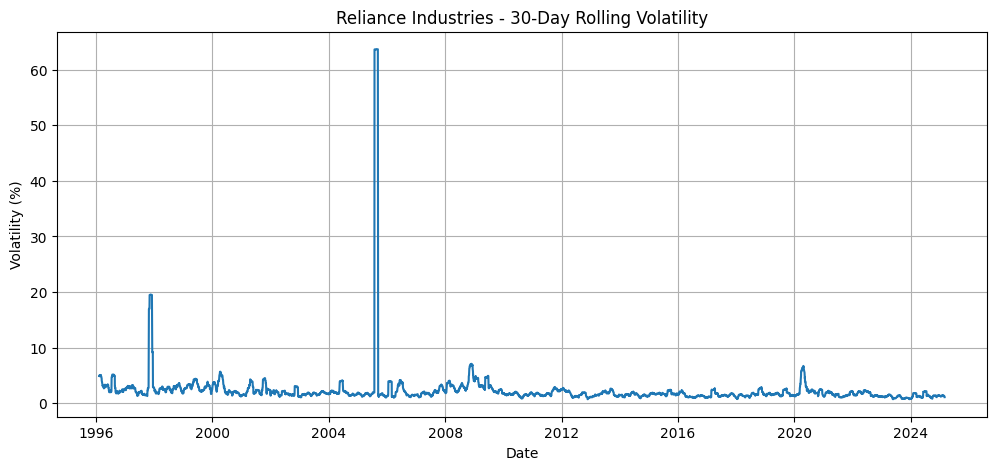

In [ ]:
# Calculate rolling 30-day volatility
df["rolling_volatility"] = (
    df["daily_return"].rolling(window=30).std()
)

# Create chart
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["rolling_volatility"])

plt.title("Reliance Industries - 30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")
plt.grid(True)

plt.savefig(
    "reliance_rolling_volatility.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# Create a summary of the major risk indicators

risk_summary = pd.DataFrame({
    "Risk Indicator": [
        "Daily Volatility",
        "Annualized Volatility",
        "Maximum Daily Loss",
        "Maximum Drawdown"
    ],
    "Value": [
        round(df["daily_return"].std(), 2),
        round(df["daily_return"].std() * np.sqrt(252), 2),
        round(df["daily_return"].min(), 2),
        round(df["drawdown"].min(), 2)
    ]
})

display(risk_summary)

,Risk Indicator,Value
0,Daily Volatility,4.76
1,Annualized Volatility,75.64
2,Maximum Daily Loss,-76.99
3,Maximum Drawdown,-77.59


In [ ]:
risk_assessment = pd.DataFrame({
    "Risk": [
        "Price Volatility Risk",
        "Downside/Market Risk",
        "Drawdown Risk",
        "Trading Activity Risk"
    ],
    "Impact Level": [
        "High",
        "High",
        "High",
        "Medium"
    ],
    "Impact": [
        "Large price fluctuations can increase uncertainty in investment value.",
        "Sharp negative price movements can cause significant financial losses.",
        "A prolonged decline from a previous peak can substantially reduce portfolio value.",
        "Large changes in trading volume may indicate periods of unusual market activity."
    ],
    "Mitigation Strategy": [
        "Use diversification, appropriate position sizing and risk limits.",
        "Monitor market conditions and use suitable risk controls.",
        "Diversify investments and regularly review exposure to the stock.",
        "Monitor unusual volume changes together with price movements."
    ]
})

display(risk_assessment)

,Risk,Impact Level,Impact,Mitigation Strategy
0,Price Volatility Risk,High,Large price fluctuations can increase uncertai...,"Use diversification, appropriate position sizi..."
1,Downside/Market Risk,High,Sharp negative price movements can cause signi...,Monitor market conditions and use suitable ris...
2,Drawdown Risk,High,A prolonged decline from a previous peak can s...,Diversify investments and regularly review exp...
3,Trading Activity Risk,Medium,Large changes in trading volume may indicate p...,Monitor unusual volume changes together with p...


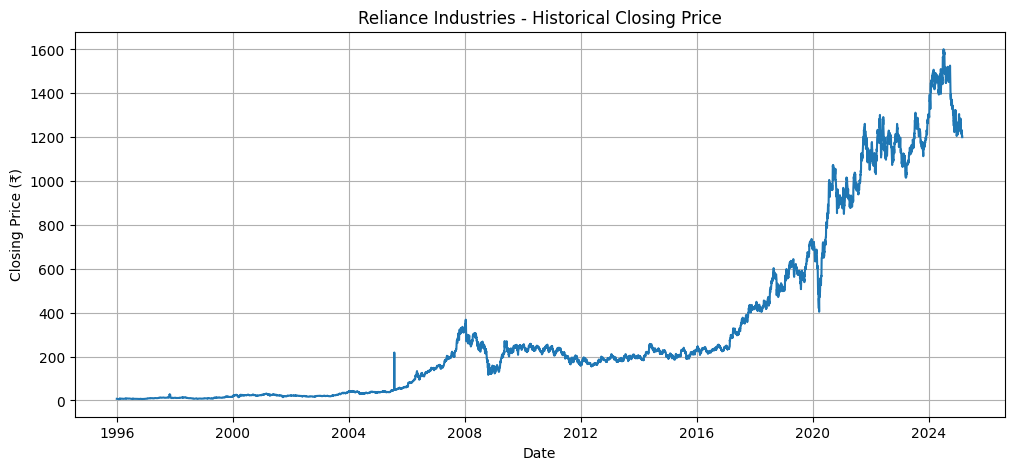

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["close"])

plt.title("Reliance Industries - Historical Closing Price")
plt.xlabel("Date")
plt.ylabel("Closing Price (₹)")
plt.grid(True)

plt.savefig(
    "reliance_closing_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()